# Step 10. Federate it: one module definition, reapplied to A, B and C

Step 07 proved pooling four sufficient statistics reproduces the pooled correlation matrix exactly,
and named the blocker: `rank(G) = min(n, p)`, and with p = 7,288 against n ≈ 87 the Gram matrix can
be inverted back toward the rows. This notebook performs the federation that step 07 only
described, under the constraint that makes it safe.

The flow is the one the constraint forces:

```
per site → 1-D summaries only (means, variances) ──► agree a panel with p < n
per site → N, S, Q, G on THAT panel ──► pooled correlation, exact
 ──► ONE module definition
 ──► reapplied to A, B, C
```

Nothing but 1-D summaries and a reduced-panel Gram ever leaves a site. No site sees another site's
patients.

In [1]:
source("../src/paths.R")
suppressMessages(library(WGCNA)); options(stringsAsFactors = FALSE); set.seed(42)
SITES <- c("A", "B", "C")
Xs <- lapply(SITES, function(s)
  as.matrix(read.csv(coh("R_cohort-%s_log2_combat.csv", s), row.names = 1, check.names = FALSE)))
names(Xs) <- SITES

N_MIN    <- min(sapply(Xs, nrow))
P_BUDGET <- 80                       # must be < N_MIN, with margin
cat(sprintf("sites: %s\n", paste(sprintf("%s n=%d", SITES, sapply(Xs, nrow)), collapse = "  ")))
cat(sprintf("smallest site n = %d  ->  panel budget p = %d   (release rule: p < n)\n",
            N_MIN, P_BUDGET))

sites: A n=87  B n=87  C n=86


smallest site n = 86  ->  panel budget p = 80   (release rule: p < n)


## Step 1, agree a panel using 1-D summaries only

Per-protein sums and sums of squares are one-dimensional. They cannot be inverted back toward an
individual the way a Gram matrix can, so they are the safest thing a site can ship. Pooling them
gives every protein's mean and variance across all three sites without any site seeing another's
patients.

**Two panels, because the choice of panel is the whole result.**

- `variance`, the top 80 proteins by pooled variance. Entirely unsupervised: no prior
  knowledge, nothing named in advance. This is what "federated discovery" would mean.
- `prior`, the 23 curated interferon-stimulated gene (ISG) probes from `proteins/interferon-response-genes.json`, plus the
  top 57 remaining by variance. Same budget, same release rule; the difference is that one module
  was named before the data was touched.

In [2]:
summ  <- lapply(Xs, function(M) list(n = nrow(M), s = colSums(M), q = colSums(M^2)))
n_tot <- sum(sapply(summ, `[[`, "n"))
s_tot <- Reduce(`+`, lapply(summ, `[[`, "s"))
q_tot <- Reduce(`+`, lapply(summ, `[[`, "q"))
mu    <- s_tot / n_tot
sdv   <- sqrt(pmax(q_tot / n_tot - mu^2, 0))        # pooled, federated

isg   <- read_ifn_panel(colnames(Xs$A))
byvar <- names(sort(sdv, decreasing = TRUE))
PANELS <- list(
  variance = byvar[seq_len(P_BUDGET)],
  prior    = c(isg, setdiff(byvar, isg)[seq_len(P_BUDGET - length(isg))]))

data.frame(panel = names(PANELS),
           p = sapply(PANELS, length),
           isg_probes = sapply(PANELS, function(p) length(intersect(p, isg))),
           of = length(isg), row.names = NULL)

panel,p,isg_probes,of
<chr>,<int>,<int>,<int>
variance,80,3,23
prior,80,23,23


## Step 2, pool the sufficient statistics, on the reduced panel only

Identical algebra to step 07. The only change is that `G` is now 80 × 80 rather than 7,288 × 7,288,
which is what makes it releasable: with p = 80 < n = 86 the Gram matrix is full rank in the protein
direction and carries no row-recoverable residual.

The gate is the same too, the federated correlation must equal the correlation computed from
pooled raw data. If it does not, the federation is not exact and nothing below it means anything.

In [3]:
suff <- function(M) { M <- as.matrix(M)
  list(N = crossprod(!is.na(M)), S = crossprod(!is.na(M), replace(M, is.na(M), 0)),
       Q = crossprod(!is.na(M), replace(M, is.na(M), 0)^2),
       G = crossprod(replace(M, is.na(M), 0))) }

pooled_cor <- function(st) {
  n <- st$N; s <- st$S; g <- st$G; q <- st$Q
  cov <- g / n - (s * t(s)) / (n * n)
  sv  <- sqrt(q / n - (s / n)^2)
  r   <- cov / (sv * t(sv))
  # Rebuilding r from sufficient statistics overshoots +-1 by ~1e-16 on
  # near-perfect pairs; WGCNA's checkAdjMat rejects that, so clamp.
  pmin(pmax(r, -1), 1)
}

federate <- function(panel) {
  st <- Reduce(function(a, b) Map(`+`, a, b),
               lapply(Xs, function(M) suff(M[, panel, drop = FALSE])))
  R  <- pooled_cor(st)
  Rd <- cor(do.call(rbind, lapply(Xs, function(M) M[, panel, drop = FALSE])))
  list(R = R, exact = max(abs(R - Rd)))
}
fed <- lapply(PANELS, federate)

for (nm in names(fed))
  cat(sprintf("%-9s p = %2d < n = %d : %-14s federated vs pooled-raw max|diff| = %.1e\n",
              nm, length(PANELS[[nm]]), N_MIN,
              if (length(PANELS[[nm]]) < N_MIN) "RELEASABLE" else "NOT RELEASABLE",
              fed[[nm]]$exact))
stopifnot(all(sapply(fed, `[[`, "exact") < 1e-9))
cat("\nGATE PASSED -- pooling sufficient statistics is exact\n")

variance  p = 80 < n = 86 : RELEASABLE     federated vs pooled-raw max|diff| = 1.0e-13
prior     p = 80 < n = 86 : RELEASABLE     federated vs pooled-raw max|diff| = 6.3e-13



GATE PASSED -- pooling sufficient statistics is exact


## Step 3, one module definition, built from the correlation matrix alone

`blockwiseModules` wants a data matrix, which a federation does not have. It does not need one: the
whole pipeline downstream of the correlation matrix is public algebra, signed adjacency, TOM,
average-linkage tree, dynamic tree cut. Running those on the pooled correlation gives the module
definition all three sites share, and it is identical to what pooled raw data would have produced.

In [4]:
define_modules <- function(R, panel) {
  sft <- pickSoftThreshold.fromSimilarity((1 + R) / 2,
           powerVector = c(1:10, seq(12, 20, 2)), verbose = 0)
  POW <- max(12, ifelse(is.na(sft$powerEstimate), 0, sft$powerEstimate))   # same floor as step 01
  TOM <- TOMsimilarity(((1 + R) / 2)^POW, verbose = 0)
  dimnames(TOM) <- list(panel, panel)
  tree <- hclust(as.dist(1 - TOM), method = "average")
  fm   <- labels2colors(cutreeDynamic(tree, distM = 1 - TOM, deepSplit = 2,
                                      minClusterSize = 5, verbose = 0))
  names(fm) <- panel
  list(mods = fm, power = POW, tree = tree)
}
defs <- lapply(names(PANELS), function(nm) define_modules(fed[[nm]]$R, PANELS[[nm]]))
names(defs) <- names(PANELS)

for (nm in names(defs)) {
  fm <- defs[[nm]]$mods; inp <- intersect(PANELS[[nm]], isg)
  named <- fm[inp][fm[inp] != "grey"]
  cat(sprintf("\n--- panel '%s' (power %d) ---\n", nm, defs[[nm]]$power))
  print(sort(table(fm), decreasing = TRUE))
  if (length(named)) {
    t1 <- sort(table(named), decreasing = TRUE)
    cat(sprintf("  ISGs concentrate in '%s': %d of %d in panel (module size %d)\n",
                names(t1)[1], t1[[1]], length(inp), sum(fm == names(t1)[1])))
  } else cat(sprintf("  %d ISG probes in panel, NONE in a named module -- not recoverable\n",
                     length(inp)))
}

Warning message:
“executing %dopar% sequentially: no parallel backend registered”


   Power SFT.R.sq   slope truncated.R.sq mean.k. median.k. max.k.
1      1   0.0996   4.270         0.5370  40.700  40.80000  43.20
2      2   0.0232   0.724         0.6680  21.300  21.30000  24.30
3      3   0.0301  -0.646         0.5640  11.400  11.40000  14.50
4      4   0.1640  -9.910         0.0281   6.330   6.23000   9.45
5      5   0.2840 -12.300         0.1230   3.650   3.44000   6.77
6      6   0.3600 -11.700         0.1820   2.240   1.94000   5.34
7      7   0.3720  -9.390         0.2030   1.470   1.10000   4.56
8      8   0.3750  -8.330         0.1960   1.050   0.62600   4.12
9      9   0.3620  -6.990         0.1850   0.818   0.35400   3.87
10    10   0.3570  -6.020         0.1990   0.682   0.20100   3.73
11    12   0.3360  -4.840         0.1590   0.546   0.07180   3.57
12    14   0.2000  -2.940        -0.0235   0.485   0.02670   3.47
13    16   0.2000  -2.730        -0.0262   0.449   0.01060   3.40
14    18   0.2100  -2.920        -0.0124   0.424   0.00451   3.33
15    20  


--- panel 'variance' (power 12) ---
fm
     grey turquoise      blue 
       69         6         5 
  3 ISG probes in panel, NONE in a named module -- not recoverable

--- panel 'prior' (power 12) ---
fm
     grey turquoise      blue 
       60        14         6 
  ISGs concentrate in 'turquoise': 13 of 23 in panel (module size 14)


## What the two panels show, and it is the answer to "can we federate?"

**Unsupervised federated discovery fails.** The `variance` panel keeps 3 of the 23 ISG probes, the
interferon proteins are not among the 80 most variable in plasma, and none of those 3 lands in a
named module. Under the release rule that makes federation safe, the interferon module cannot be
discovered. This is not a tuning problem; the proteins that carry the signature were dropped
before the correlation was ever computed, by a criterion that could not know they mattered.

**Federated confirmation works.** The `prior` panel, on the identical budget and the identical
release rule, recovers the module: the curated ISGs concentrate into a single module of about
fourteen proteins, the same size step 02 found on the full 7,288-protein panel at one site.

What federation buys here:

> Discovery needs the full panel and therefore one site. Confirmation federates exactly, on a
> panel small enough to release, provided the thing being confirmed was named in advance.

This is why `proteins/interferon-response-genes.json` is committed prior knowledge rather than a
by-product of the fit. It is the object that makes the federated arm possible.

Everything below uses the `prior` panel.

In [5]:
USE   <- "prior"
panel <- PANELS[[USE]]; R <- fed[[USE]]$R; fmods <- defs[[USE]]$mods
mlist <- setdiff(unique(fmods), "grey")

# Federated loadings: PC1 of each module's POOLED correlation submatrix. No
# site's data is needed to compute them, and every site uses the same numbers --
# which is what makes the scores comparable across A, B and C at all.
loadings <- lapply(mlist, function(k) {
  g <- names(fmods)[fmods == k]
  v <- eigen(R[g, g, drop = FALSE], symmetric = TRUE)$vectors[, 1]
  names(v) <- g
  if (sum(v) < 0) v <- -v          # align so it tracks the module's mean abundance
  v
})
names(loadings) <- mlist

# Each site scores ITSELF, with pooled centring and scaling -- also federated.
score_site <- function(M) {
  Zs <- scale(M[, panel, drop = FALSE], center = mu[panel], scale = sdv[panel])
  sapply(mlist, function(k) as.vector(Zs[, names(loadings[[k]])] %*% loadings[[k]]))
}
E <- lapply(Xs, score_site)
for (s in SITES) rownames(E[[s]]) <- rownames(Xs[[s]])
cat(sprintf("%d shared modules scored at every site\n\n", length(mlist)))
sapply(E, dim)

2 shared modules scored at every site



A,B,C
87,87,86
2,2,2


## Step 4, the same modules, drawn at all three sites

Identical columns in all three panels: the same proteins, in the same order, grouped by the same
federated module definition. Only the patients differ. Rows are clustered within each site but not
split, step 05 found no patient partition survives cross-validation, so imposing one here would be
drawing a conclusion the data does not support.

**What to look for:** whether the column blocks show the same vertical banding at B and C as at A.
That is the federation question, does a module defined by pooling mean the same thing at a site
that did not define it.

In [6]:
suppressMessages({library(ComplexHeatmap); library(circlize); library(grid)})
ordm <- mlist[order(sapply(mlist, function(k) sum(fmods == k)))]
sel  <- unlist(lapply(ordm, function(k) names(fmods)[fmods == k]))
modf <- factor(fmods[sel], levels = ordm)
ifn_mod <- names(sort(table(fmods[intersect(panel, isg)][
             fmods[intersect(panel, isg)] != "grey"]), decreasing = TRUE))[1]

panel_ht <- function(s) {
  # Pooled centring again, so the colour scale means the same thing at each site.
  Z <- scale(Xs[[s]][, sel, drop = FALSE], center = mu[sel], scale = sdv[sel])
  Heatmap(Z, name = "z-score",
    col = colorRamp2(c(-2, 0, 2), c("#2166AC", "white", "#B2182B")),
    column_split = modf, cluster_rows = TRUE, cluster_columns = FALSE,
    clustering_method_rows = "ward.D2",
    show_row_dend = TRUE, row_dend_width = unit(14, "mm"), show_row_names = FALSE,
    column_names_gp = gpar(fontsize = 4), column_title_gp = gpar(fontsize = 7),
    column_title_rot = 90,
    heatmap_legend_param = list(labels_gp = gpar(fontsize = 7),
                                title_gp = gpar(fontsize = 8)),
    row_title = sprintf("cohort %s, n = %d", s, nrow(Xs[[s]])))
}
hts <- lapply(SITES, panel_ht); names(hts) <- SITES

png(art("fig10_federated_ABC.png"), width = 3600, height = 1500, res = 150)
grid.newpage(); pushViewport(viewport(layout = grid.layout(1, 3)))
for (i in seq_along(SITES)) {
  pushViewport(viewport(layout.pos.row = 1, layout.pos.col = i))
  draw(hts[[i]], newpage = FALSE,
       column_title = sprintf("cohort %s -- federated modules (p = %d, interferon = %s)",
                              SITES[i], length(panel), ifn_mod),
       column_title_gp = gpar(fontsize = 10, fontface = "bold"))
  popViewport()
}
popViewport(); invisible(dev.off())
cat("wrote", art("fig10_federated_ABC.png"), "\n")

wrote /Users/adeslatt/Scitechcon Dropbox/Anne DeslattesMays/projects/endotypes-proteomics/data/run_artifacts/fig10_federated_ABC.png 


In [7]:
# Does the module hold together at sites that did not define it? Mean within-module
# correlation per site, on the shared definition. This is the number the picture shows.
coh_tab <- do.call(rbind, lapply(mlist, function(k) {
  g <- names(fmods)[fmods == k]
  r <- sapply(SITES, function(s) {
    C <- cor(Xs[[s]][, g, drop = FALSE]); mean(C[upper.tri(C)])
  })
  data.frame(module = k, n_proteins = length(g),
             A = round(r["A"], 2), B = round(r["B"], 2), C = round(r["C"], 2),
             interferon = k == ifn_mod)
}))
print(coh_tab[order(-coh_tab$n_proteins), ], row.names = FALSE)

saveRDS(list(panels = PANELS, fed = fed, defs = defs, use = USE, panel = panel,
             mods = fmods, loadings = loadings, E = E, mu = mu[panel], sd = sdv[panel],
             coherence = coh_tab, ifn_mod = ifn_mod, n = sapply(Xs, nrow),
             n_min = N_MIN, p_budget = P_BUDGET),
        art("federated_modules.rds"))

    module n_proteins    A    B    C interferon
 turquoise         14 0.51 0.37 0.45       TRUE
      blue          6 0.69 0.72 0.78      FALSE


## What this leaves

**Federation is exact and safe on a named panel.** The gate holds to ~1e-12, the release rule
`p < n` is satisfied with margin, and the module definition is built from a correlation matrix that
no site could invert back to a patient.

**It cannot discover.** The `variance` panel is the control, and it fails. Any federated
design for this data has to accept that the panel is chosen with prior knowledge, and say so, the
alternative is a federated analysis that is safe, exact, and blind to the one module with evidence
behind it.

**Still open.** `modulePreservation` across A, B and C on the full panel, the within-module
coherence table above is a summary statistic, not the permutation-based preservation statistic, and whether the federated module and the single-site `ivory` module contain the same proteins, not
merely the same count.

## Figures

Written to `data/run_artifacts/`: the three cohorts on one federated module definition.


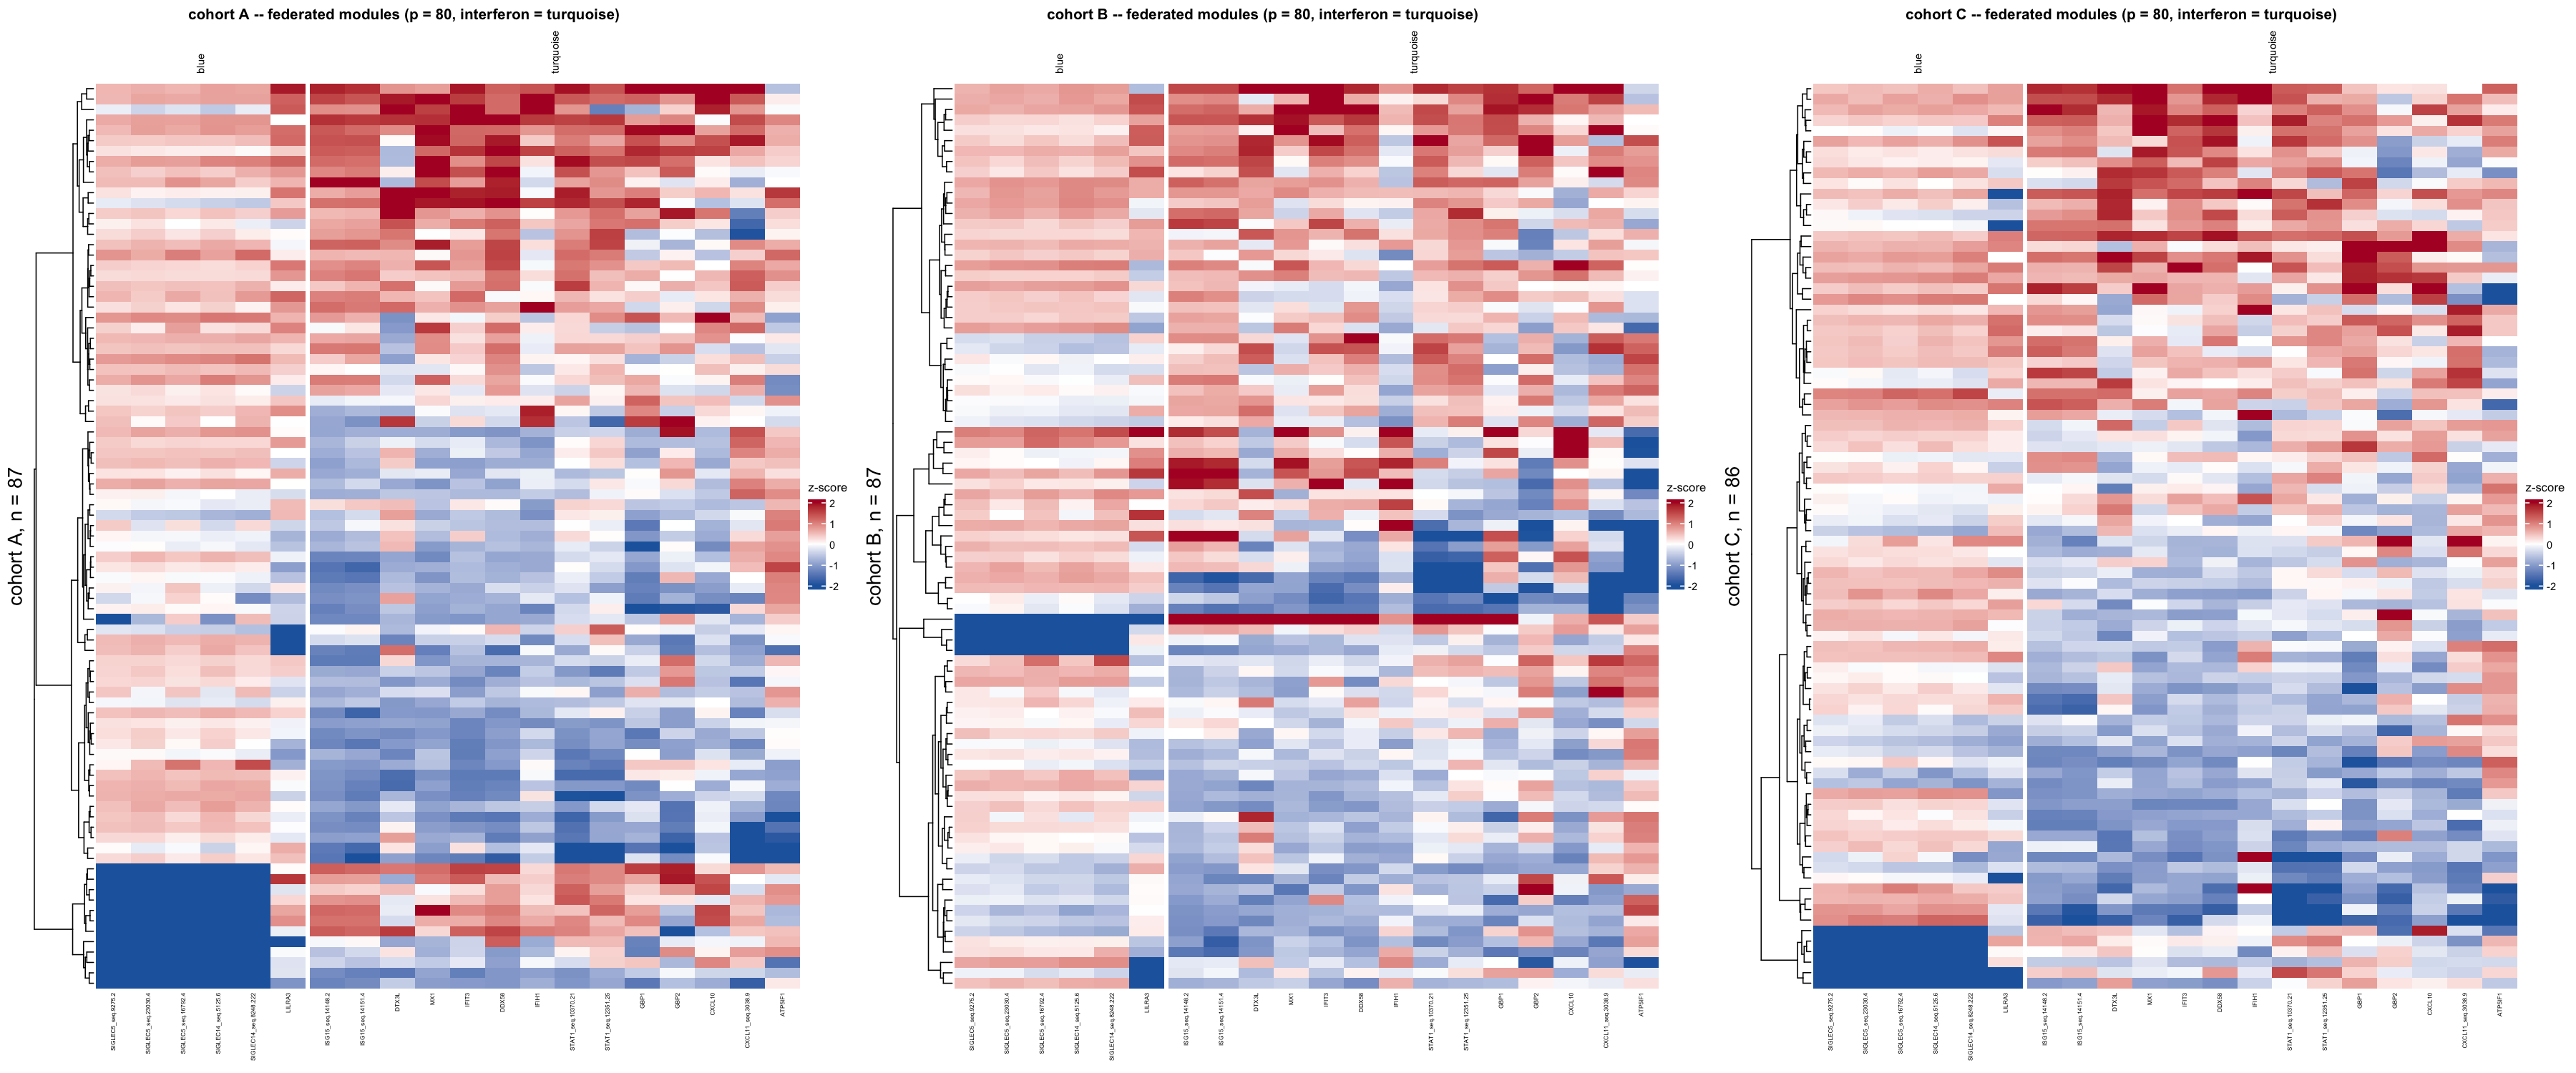

fig10_federated_ABC.png 


In [8]:
show_figures("^fig10_.*\\.png$")

## Where this was run

Rendered notebooks are committed, so each records the machine, the R and the
package versions that produced its output.


In [9]:
run_provenance()

run on   : Annes-MacBook-Pro-193.local ( Darwin 27.0.0 )
date     : 2026-09-25 12:04 EDT 
R        : R version 4.4.3 (2025-02-28) | x86_64-apple-darwin13.4.0 
R comes from: /Users/adeslatt/miniforge3/envs/endotypes-proteomics 
packages :
   WGCNA            1.74
   ComplexHeatmap   2.22.0
   sva              3.54.0
   VarSelLCM        2.1.3.2
   cluster          2.1.8.1
   fpc              2.2.15
   circlize         0.4.18
